# Open-source climate data — IMD gridded exercise

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anantrajj7-sketch/lecture-deck/blob/main/imd_gridded_clip_exercise.ipynb)

Downloading IMD gridded rainfall data with `imdlib`, opening it as an `xarray` grid, and clipping it to a study area with a 33 km buffer around a shapefile.

Run each cell top to bottom. Cells you need to edit for your own study area are marked **EDIT ME**.


## 1. Install the libraries

Nothing is pre-installed in a fresh Colab runtime — this cell pulls in everything we need. Only needs to run once per session.


In [1]:
!pip install -q imdlib geopandas shapely



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Adani\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Download the IMD gridded data

We'll pull all three variables IMD provides -- rainfall, min temperature, and max temperature -- across the same year range, since the goal is one GeoPackage with all three inside. **EDIT ME**: change the year range for your own use case.


In [2]:
import imdlib as imd
import numpy as np

VARIABLES = ['rain', 'tmin', 'tmax']
start_year = 2020   # EDIT ME
end_year = 2023     # EDIT ME

FILL_VALUES = {'rain': -999, 'tmax': 99.9, 'tmin': 99.9}   # IMD's no-data value differs by variable

datasets = {}
for variable in VARIABLES:
    imd.get_data(variable, start_year, end_year, fn_format='yearwise')
    data = imd.open_data(variable, start_year, end_year, 'yearwise')
    ds = data.get_xarray()
    ds[variable] = ds[variable].where(~np.isclose(ds[variable], FILL_VALUES[variable]))
    datasets[variable] = ds

datasets['rain']


Downloading: rain for year 2020


Downloading: rain for year 2021


Downloading: rain for year 2022


Downloading: rain for year 2023


Download Successful !!!


...

Downloading: maxtemp for year 2021


Downloading: maxtemp for year 2022


Downloading: maxtemp for year 2023


Download Successful !!!


<xarray.Dataset> Size: 204MB
Dimensions:  (time: 1461, lat: 129, lon: 135)
Coordinates:
  * time     (time) datetime64[us] 12kB 2020-01-01 2020-01-02 ... 2023-12-31
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
Data variables:
    rain     (time, lat, lon) float64 204MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2026-07-28 06:10:02.414856 Python
    references:   
    comment:      
    crs:          epsg:4326

Before moving on: IMD's grid marks cells with no data (mostly ocean, outside India's landmass) with a fill number instead of `NaN` — **-999 for rainfall**, but **99.9 for temperature** (verified against real downloads of both). `get_xarray()` does **not** convert either one for you, so the loop above masks each variable by its own fill value. Skipping this would silently wreck an average later, and differently for temperature than for rainfall.


## 3. Recall: pulling a single point

This is the part you've already done before -- picking one lat/lon out of the grid. Shown here for rainfall; the same .sel() works on any of the three datasets.


In [3]:
# EDIT ME: your point of interest
point_lat, point_lon = 28.6, 77.2   # Delhi, as an example

point_series = datasets['rain']['rain'].sel(lat=point_lat, lon=point_lon, method='nearest')
point_series.to_dataframe().reset_index().head()


,time,lat,lon,rain
0,2020-01-01,28.5,77.25,0.0
1,2020-01-02,28.5,77.25,0.0
2,2020-01-03,28.5,77.25,0.0
3,2020-01-04,28.5,77.25,0.0
4,2020-01-05,28.5,77.25,0.0


## 4. Load your shapefile

**Option A (recommended for this class)** -- pick your Maharashtra district by name, it downloads automatically, no upload needed.

**Option B** -- upload your own zipped shapefile instead, if you're working with a different area.


Found 1 match(es) for PUNE


<Axes: >

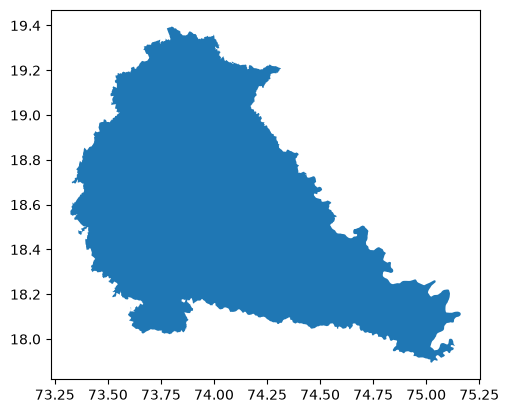

In [4]:
import geopandas as gpd

# All 36 Maharashtra districts (spelling matches the GeoPackage exactly):
#   AHAMADNAGAR, AKOLA, AMARAVATI, AURANGABAD
#   BHANDARA, BID, BULDHANA, CHANDRAPUR
#   DHULE, GADCHIROLI, GONDIA, HINGOLI
#   JALGAON, JALNA, KOLHAPUR, LATUR
#   MUMBAI CITY, NAGPUR, NANDED, NANDURBAR
#   NASHIK, PALGHAR, PARBHANI, PUNE
#   RATNAGIRI, RAYGAD, SANGLI, SATARA
#   SINDHUDURG, SOLAPUR, SUB URBAN MUMBAI, THANE
#   USMANABAD, WARDHA, WASHIM, YAVATMAL
DISTRICT = 'PUNE'   # EDIT ME -- your Maharashtra district, spelled exactly as in the list above

GPKG_URL = 'https://raw.githubusercontent.com/anantrajj7-sketch/lecture-deck/main/static/Data/maharashtra_districts.gpkg'
!wget -q {GPKG_URL} -O maharashtra_districts.gpkg

all_districts = gpd.read_file('maharashtra_districts.gpkg', layer='districts')
gdf = all_districts[all_districts['District'].str.upper().str.strip() == DISTRICT.upper()]

print('Found', len(gdf), 'match(es) for', DISTRICT)
gdf.plot()


### Option B: upload your own shapefile instead

Skip the cell above and run these two instead if you're working outside Maharashtra. Upload a **zipped** shapefile -- a `.zip` containing the `.shp`, `.shx`, `.dbf`, and (ideally) `.prj` files together. Zipping avoids having to upload four separate files one at a time.


In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()  # choose your shapefile .zip
zip_name = next(iter(uploaded))

extract_dir = 'shapefile'
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)

shp_files = [f for f in os.listdir(extract_dir) if f.endswith('.shp')]
shp_path = os.path.join(extract_dir, shp_files[0])
print('Using shapefile:', shp_path)


In [ ]:
import geopandas as gpd

gdf = gpd.read_file(shp_path).to_crs(epsg=4326)
gdf.plot()


## 5. Buffer the shapefile by 33 km

Buffering in degrees is wrong — a degree of longitude isn't a fixed distance, so the buffer would be a different real-world size depending on latitude. `estimate_utm_crs()` picks the right metric (meters-based) projection automatically, so we can buffer in meters and reproject back.


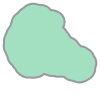

In [5]:
BUFFER_METERS = 33_000   # EDIT ME if you need a different buffer distance

utm_crs = gdf.estimate_utm_crs()
buffered_metric = gdf.to_crs(utm_crs).buffer(BUFFER_METERS)
boundary = gpd.GeoSeries(buffered_metric, crs=utm_crs).to_crs(epsg=4326).union_all()
boundary


## 6. Clip every variable's grid to the buffer

Rainfall is a 0.25 degree grid, but temperature is 1 degree -- different shapes, different coordinates. So this repeats the point-in-polygon clip once per variable rather than reusing a single grid.


In [6]:
import xarray as xr
from shapely.geometry import Point

clipped_gdfs = {}

for variable, ds in datasets.items():
    lat_vals = ds.lat.values
    lon_vals = ds.lon.values
    lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

    grid_points = gpd.GeoDataFrame(
        geometry=[Point(x, y) for x, y in zip(lon2d.ravel(), lat2d.ravel())],
        crs='EPSG:4326',
    )
    inside_2d = grid_points.within(boundary).values.reshape(lat2d.shape)
    mask = xr.DataArray(inside_2d, dims=['lat', 'lon'], coords={'lat': lat_vals, 'lon': lon_vals})

    clipped = ds[variable].where(mask)
    points_df = clipped.to_dataframe().reset_index().dropna(subset=[variable])
    points_gdf = gpd.GeoDataFrame(
        points_df,
        geometry=[Point(lon, lat) for lon, lat in zip(points_df['lon'], points_df['lat'])],
        crs='EPSG:4326',
    )
    clipped_gdfs[variable] = points_gdf
    print(variable, '-', len(points_gdf), 'rows kept')


rain - 75972 rows kept
tmin - 4383 rows kept


tmax - 4383 rows kept


## 7. Visual check

Plot the shapefile, the 33 km buffer, and the surviving points from all three variables together -- a quick way to confirm the clip did what you expect before trusting the numbers. Temperature points are drawn larger since there are far fewer of them (1 degree grid vs. rainfall's 0.25 degree grid).


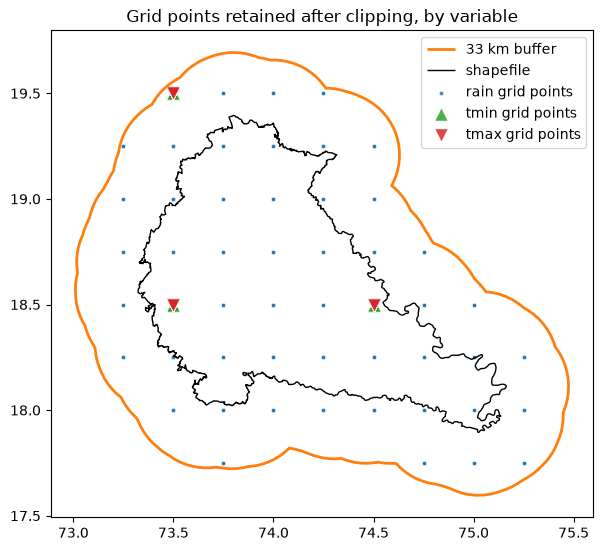

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
gpd.GeoSeries([boundary], crs='EPSG:4326').boundary.plot(ax=ax, color='tab:orange', linewidth=2, label='33 km buffer')
gdf.boundary.plot(ax=ax, color='black', linewidth=1, label='shapefile')

styles = {
    'rain': dict(color='tab:blue', s=10, marker='o'),
    'tmin': dict(color='tab:green', s=90, marker='^'),
    'tmax': dict(color='tab:red', s=90, marker='v'),
}
for variable, points_gdf in clipped_gdfs.items():
    style = styles[variable]
    ax.scatter(points_gdf['lon'], points_gdf['lat'], label=f'{variable} grid points',
               edgecolor='white', linewidth=0.5, alpha=0.85, **style)

ax.legend()
ax.set_title('Grid points retained after clipping, by variable')
plt.show()


## 8. Save each variable as a CSV

One row per grid point, one column per date -- pivot() reshapes points_gdf from one row per (time, lat, lon) into that layout, the one most people actually expect when they open a CSV in a spreadsheet. Fill values are already gone -- dropped in step 6 along with the rest of the NaNs.


In [8]:
for variable, points_gdf in clipped_gdfs.items():
    wide = points_gdf.pivot(index=['lat', 'lon'], columns='time', values=variable)
    wide.columns = [c.strftime('%Y-%m-%d') for c in wide.columns]

    csv_path = f'clipped_{variable}.csv'   # EDIT ME if you'd like different filenames
    wide.to_csv(csv_path)
    print('Saved', wide.shape[0], 'rows x', wide.shape[1], 'date columns to', csv_path)


Saved 52 rows x 1461 date columns to clipped_rain.csv
Saved 3 rows x 1461 date columns to clipped_tmin.csv
Saved 3 rows x 1461 date columns to clipped_tmax.csv


## 9. Save all three into one GeoPackage

A GeoPackage can hold multiple tables in a single file -- so rain, tmin, and tmax each get their own layer here, instead of three separate files. Same pivot as the CSV step: one row per grid point, one column per date, plus the geometry a GIS tool needs. Opening clipped_points.gpkg in QGIS shows all three as separate layers to toggle on and off.


In [9]:
import os

GPKG_PATH = 'clipped_points.gpkg'   # EDIT ME if you'd like a different filename
if os.path.exists(GPKG_PATH):
    os.remove(GPKG_PATH)   # start clean -- re-running this cell shouldn't fight with layers from a previous run

for variable, points_gdf in clipped_gdfs.items():
    wide = points_gdf.pivot(index=['lat', 'lon'], columns='time', values=variable)
    wide.columns = [c.strftime('%Y-%m-%d') for c in wide.columns]
    wide = wide.reset_index()

    geoms = points_gdf.drop_duplicates(subset=['lat', 'lon'])[['lat', 'lon', 'geometry']]
    wide_gdf = gpd.GeoDataFrame(wide.merge(geoms, on=['lat', 'lon']), geometry='geometry', crs='EPSG:4326')

    mode = 'a' if os.path.exists(GPKG_PATH) else 'w'
    wide_gdf.to_file(GPKG_PATH, layer=variable, driver='GPKG', mode=mode)

print('Saved layers:', list(clipped_gdfs.keys()), 'to', GPKG_PATH)

from google.colab import files
files.download(GPKG_PATH)   # prompts your browser to save it locally


Saved layers: ['rain', 'tmin', 'tmax'] to clipped_points.gpkg


## Recap

- Point vs. gridded data -- you pulled both a single point (step 3) and clipped a full region (steps 4-6) from the same downloaded grids.
- The grids were never "just your basin" -- imdlib always downloads the whole country; clipping is something *you* do afterward.
- Buffering must happen in a metric CRS, not directly in degrees.
- IMD's fill value is never `NaN` -- it's -999 for rainfall but 99.9 for temperature -- always mask it, by variable, before averaging.
- Rainfall (0.25 degree) and temperature (1 degree) grids have different shapes, so clipping is repeated per variable, not done once.
- CSV is fine for a quick look, but the GeoPackage (step 9) keeps geometry, CRS, and all three variables as separate layers in one file -- the right format to hand to a GIS tool.
